Notebook to test training data generator

To generate full training data sets:

    for level in 0.00 0.20 0.40 0.60 0.80; 
    do python make_training_data.py --path training_data/d$level --size 500000 --difficulty $level; 
    done



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob
from make_training_data import make_training_data, PipetteTemplates, NoiseData

In [2]:
#template = PipetteTemplate('yip_2019_template.npz')
template = PipetteTemplates(glob.glob('template_data/template_*.npz'))
# template = PipetteTemplate('template_data/template_002.npz')

noise_data = NoiseData(glob.glob('template_data/background_data/ImageSequence*/image_000.ma'))


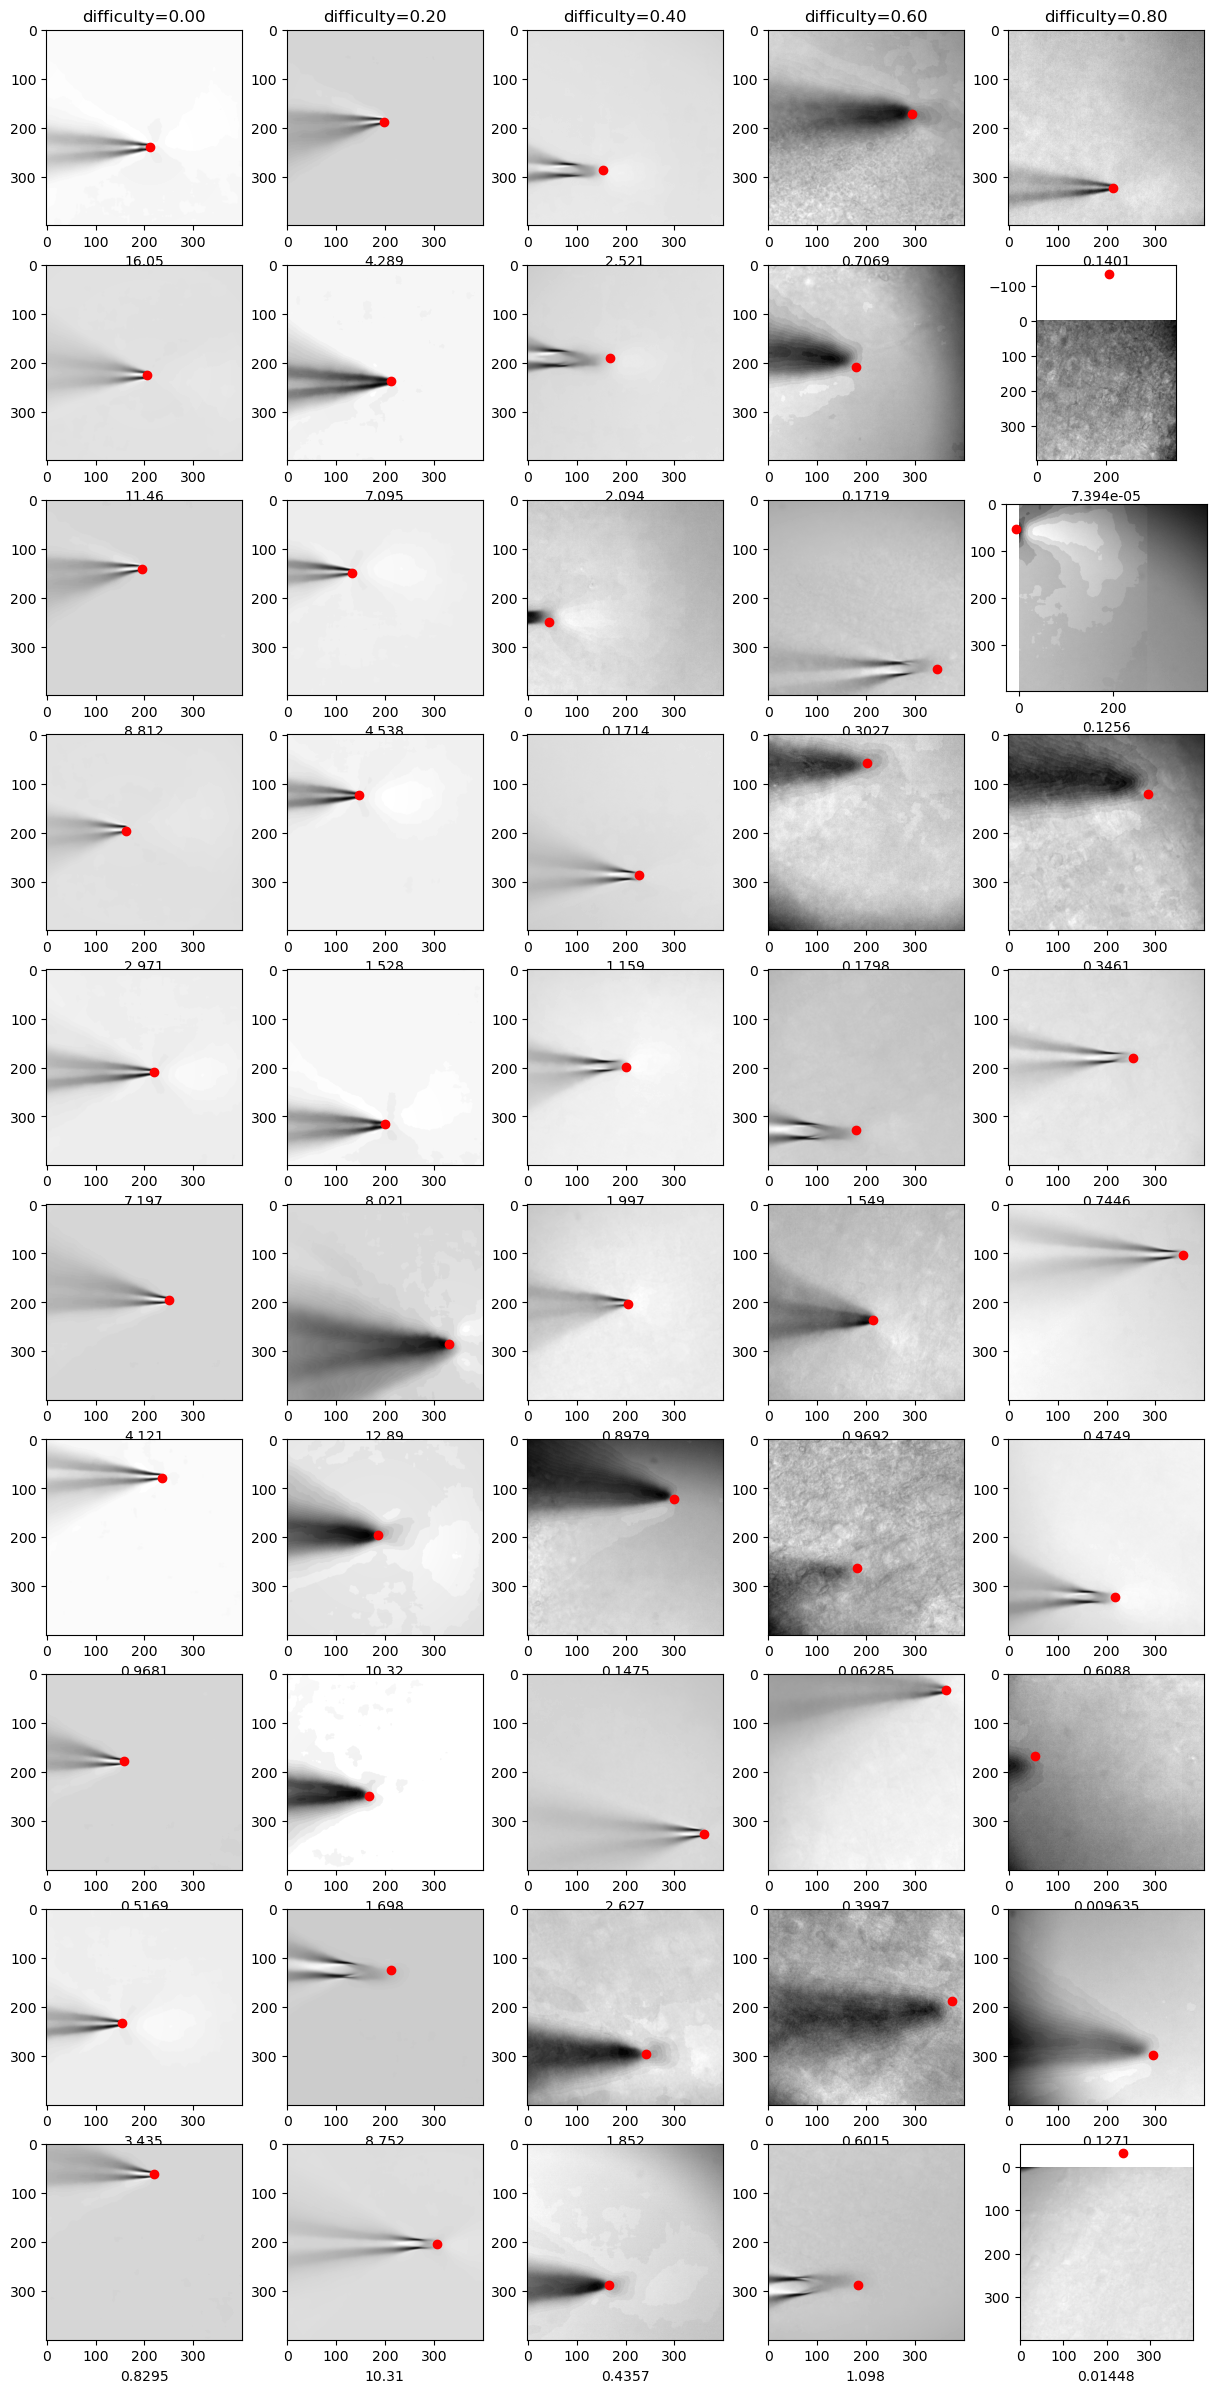

In [3]:
levels = [0, 0.2, 0.4, 0.6, 0.8]
shape = (10, len(levels))

fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

for j in range(shape[1]):
    difficulty = levels[j]
    ax[0,j].set_title(f"difficulty={difficulty:0.2f}")
    for i in range(shape[0]):
        image, pip_pos, image_stats = make_training_data(difficulty=difficulty, size=400, template=template, noise_data=noise_data)
        ax[i,j].imshow(image, cmap='gray')
        ax[i,j].scatter(pip_pos[2], pip_pos[1], color='red')
        ax[i,j].set_xlabel(f"{image_stats['pip_visibility']:.4g}")